# Automatic differentiation

This example notebook shows how one can leverage `JAX`'s automatic differentiation capabilities to compute derivatives of functions, even if they involve solving the TOV equations as intermediate step. 

Have a look at the other example notebook to see in detail how to construct the EOS and solve the TOV equations for the metamodel and speed-of-sound parameterization.

**NOTE**: This example notebook requires additional dependencies for the Adam optimizer. 

In [14]:
from typing import Callable
import numpy as np
import matplotlib.pyplot as plt

params = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Serif"],
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,
}
plt.rcParams.update(params)
import matplotlib.cm as cm
import matplotlib.colors as colors

import jax
import jax.numpy as jnp

from jesterTOV.eos.metamodel.metamodel_CSE import MetaModel_with_CSE_EOS_model
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.data_classes import EOSData, FamilyData

## EOS and TOV setup

First, we will define the EOS class used to construct the EOS quantities

In [15]:
nsat = 0.16  # nuclear saturation density in fm^-3
N_CSE = 8  # number of CSE grid points
NMAX_NSAT = 12.0  # maximum density to consider in nsat
# Note; we are fixing the proton fraction
eos = MetaModel_with_CSE_EOS_model(nmax_nsat=NMAX_NSAT, proton_fraction=0.05)

We set up the TOV solver and a helper lambda that will be reused inside the transform function:

In [16]:
gr_tov_solver = GRTOVSolver()
construct_family_lambda = lambda eos_data: gr_tov_solver.construct_family(eos_data, ndat=100, min_nsat=1.0, tov_params={})

We define an auxiliary function that constructs the EOS and solves the TOV equations given a dictionary of parameters. `JAX` can differentiate functions that take dictionaries as arguments, which lets us compute gradients with respect to any EOS parameter. The function merges the varying parameters with any fixed parameters before passing the full set to `construct_eos`.

In [17]:
def transform_func(
    params: dict[str, float], fixed_params: dict[str, float]
) -> dict[str, float]:
    """
    Auxiliary transformation function that takes a dict of EOS parameters and returns
    neutron-star family observables (masses, radii, tidal deformabilities).

    JAX differentiates with respect to the first argument `params`. Parameters that
    should remain fixed during optimization are passed via `fixed_params`.
    """
    # Merge varying and fixed parameters into a single dict for construct_eos
    all_params = {**params, **fixed_params}

    # Build EOS data using the unified API
    eos_data: EOSData = eos.construct_eos(all_params)

    # Solve the TOV equations to get the neutron-star family
    family: FamilyData = construct_family_lambda(eos_data)

    return {
        "masses_EOS": family.masses,
        "radii_EOS": family.radii,
        "Lambdas_EOS": family.lambdas,
    }

We can fix some parameters, if desired:

In [18]:
# Choose for an empty dict for the fixed parameters if all are varied:
fixed_params = {}

# Fix some parameters -- here, E_sat and the CSE density grid-point locations.
# The _u suffix denotes uniform [0, 1] parameters that are internally mapped to [nbreak, nmax].
fixed_params["E_sat"] = -16.0
for i in range(N_CSE):
    fixed_params[f"n_CSE_{i}_u"] = (i + 1) / (N_CSE + 1)

print("Fixed params are:")
for key, value in fixed_params.items():
    print(f"    {key}: {value}")

Fixed params are:
    E_sat: -16.0
    n_CSE_0_u: 0.1111111111111111
    n_CSE_1_u: 0.2222222222222222
    n_CSE_2_u: 0.3333333333333333
    n_CSE_3_u: 0.4444444444444444
    n_CSE_4_u: 0.5555555555555556
    n_CSE_5_u: 0.6666666666666666
    n_CSE_6_u: 0.7777777777777778
    n_CSE_7_u: 0.8888888888888888


Now, let us choose some starting parameters

In [19]:
starting_parameters = {
    "E_sat": -16.0,  # metamodel saturation energy parameters
    "K_sat": 200.0,
    "Q_sat": 0.0,
    "Z_sat": 0.0,
    "E_sym": 32.0,  # metamodel symmetry energy parameters
    "L_sym": 40.0,
    "K_sym": -100.0,
    "Q_sym": 0.0,
    "Z_sym": 0.0,
}

# Add the nbreak parameter
starting_parameters["nbreak"] = 1.5 * nsat

# Add the CSE parameters
# n_CSE_i_u are uniform [0, 1] density fractions, internally mapped to [nbreak, nmax]
for i in range(N_CSE):
    starting_parameters[f"n_CSE_{i}_u"] = (i + 1) / (N_CSE + 1)
    starting_parameters[f"cs2_CSE_{i}"] = 0.5

# Don't forget to add the final cs2 value, which is fixed at nmax
starting_parameters[f"cs2_CSE_{N_CSE}"] = 0.5

# Remove the fixed parameters from the starting parameters:
for key, value in fixed_params.items():
    if key in starting_parameters:
        del starting_parameters[key]

# Show starting parameters to the user
print("Starting parameters are:")
for key, value in starting_parameters.items():
    print(f"    {key}: {value}")
print(f"Optimization will be in {len(starting_parameters)} dimensional EOS space.")

Starting parameters are:
    K_sat: 200.0
    Q_sat: 0.0
    Z_sat: 0.0
    E_sym: 32.0
    L_sym: 40.0
    K_sym: -100.0
    Q_sym: 0.0
    Z_sym: 0.0
    nbreak: 0.24
    cs2_CSE_0: 0.5
    cs2_CSE_1: 0.5
    cs2_CSE_2: 0.5
    cs2_CSE_3: 0.5
    cs2_CSE_4: 0.5
    cs2_CSE_5: 0.5
    cs2_CSE_6: 0.5
    cs2_CSE_7: 0.5
    cs2_CSE_8: 0.5
Optimization will be in 18 dimensional EOS space.


How does our initial guess look like?

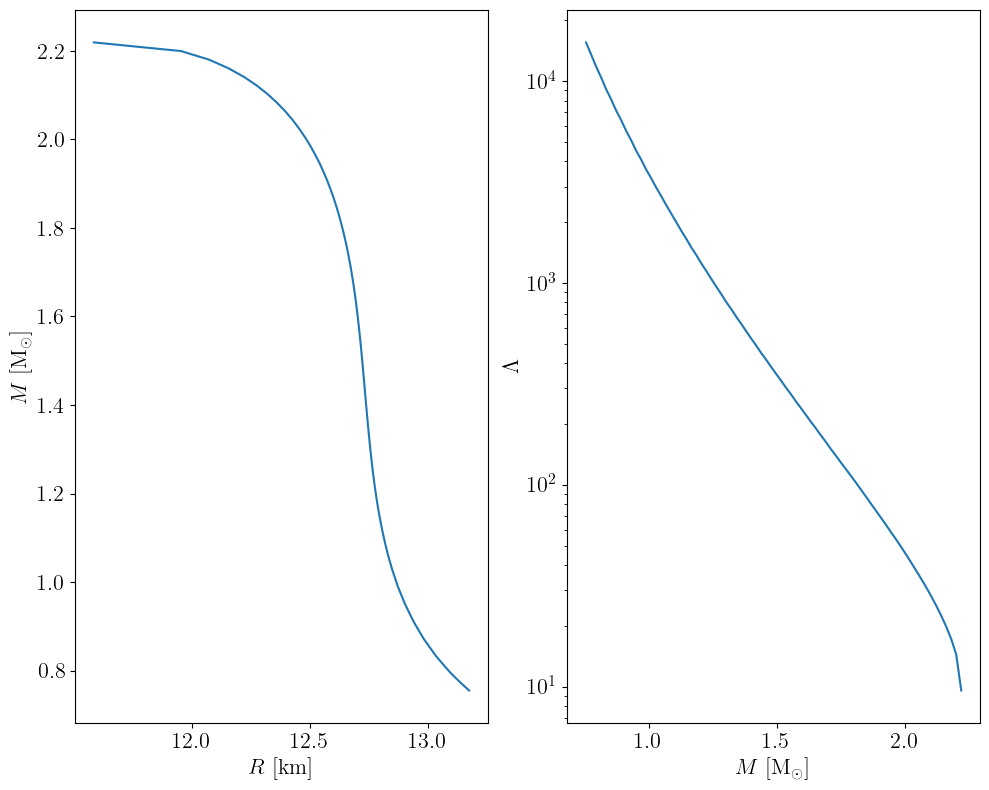

In [20]:
# Solve the TOV equations
out = transform_func(starting_parameters, fixed_params)
m, r, l = out["masses_EOS"], out["radii_EOS"], out["Lambdas_EOS"]

plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
mask = m > 0.75
plt.subplot(121)
plt.plot(r[mask], m[mask])
plt.xlabel(r"$R$ [km]")
plt.ylabel(r"$M$ [M$_\odot$]")

plt.subplot(122)
plt.plot(m[mask], l[mask])
plt.xlabel(r"$M$ [M$_\odot$]")
plt.ylabel(r"$\Lambda$")
plt.yscale("log")
plt.tight_layout()
plt.show()
plt.close()

## Score functions

Next, we should define what score or objective function we wish to optimize for. Here, we will use two toy examples:
- A function that returns the maximal allowed mass of a neutron star
- A function that computes the deviation from a given radius at 1.4$M_\odot$. This lies at the basis of the numerical, gradient-based inversion scheme proposed in the `jester` paper.
For each, we allow for a sign parameter to either maximize or minimize the score function.

Note: in order to use `jax.grad` later on, the objective functions must return a scalar value. For vector-valued output, `jax.jacfwd`, `jax.jacrev` should be used. 

In [21]:
def score_fn_mtov(
    params: dict[str, float], fixed_params: dict[str, float], sign=-1
) -> tuple:
    """
    Score function where the score is the TOV mass of the EOS corresponding to params.
    The sign is used to indicate whether we want to maximize or minimize the score.

    Note that we return the output of the TOV solver in the second argument, which JAX will consider as "aux" in `jax.grad`
    """

    out = transform_func(params, fixed_params)
    mtov = jnp.max(out["masses_EOS"])
    score = sign * mtov
    return score, out


def score_fn_radius(
    params: dict[str, float],
    fixed_params: dict[str, float],
    sign=+1,
    target_radius: float = 12.0,
) -> tuple:
    """
    Score function where the score is the Lambda value at 1.4 Msun of the EOS corresponding to params.
    The sign is used to indicate whether we want to maximize or minimize the score.

    Note that we return the output of the TOV solver in the second argument, which JAX will consider as "aux" in `jax.grad`
    """

    out = transform_func(params, fixed_params)
    m, r = out["masses_EOS"], out["radii_EOS"]
    R14 = jnp.interp(1.4, m, r)
    score = sign * jnp.abs(R14 - target_radius)
    return score, out

# Optimizer setup

Let us now define the master function that performs several loops of gradient descent with a given learning rate (step size).

Note: to make use of the Adam optimizer, we will use functions from `optax`, which is a library for gradient-based optimization in `JAX`. We also use `tqdm` for a nice progress bar. These are not in the requirements when installing `jester` (since the core functionality does not require it), so you will need to install it separately if you want to run this notebook.

In [22]:
try:
    import optax
    import tqdm
except ImportError:
    raise ImportError(
        "optax and tqdm is not installed. Please install it with 'pip install optax tqdm' for this notebook."
    )

In [23]:
def run(
    score_fn: Callable,
    starting_parameters: dict[str, float],
    fixed_params: dict[str, float],
    sign: int = -1,
    nb_steps: int = 200,
    learning_rate: float = 1e-3,
):

    print("Computing by gradient ascent . . .")
    pbar = tqdm.tqdm(range(nb_steps))

    # Define the score function with gradient applied to it. We only differentiate with respect to the first argument.
    score_fn_with_sign = lambda params, fixed_params: score_fn(
        params, fixed_params, sign
    )
    score_fn_with_grad = jax.jit(
        jax.value_and_grad(score_fn_with_sign, argnums=0, has_aux=True)
    )

    # Will store the results per iteration in a dict
    trajectory = {}
    params = starting_parameters.copy()

    # Initialize the optimizer
    gradient_transform = optax.adam(learning_rate=learning_rate)
    opt_state = gradient_transform.init(params)

    for i in pbar:
        (score, aux), grad = score_fn_with_grad(params, fixed_params)
        m, r, l = aux["masses_EOS"], aux["radii_EOS"], aux["Lambdas_EOS"]

        # Check for NaNs
        if np.any(np.isnan(m)) or np.any(np.isnan(r)) or np.any(np.isnan(l)):
            print(f"Iteration {i} has NaNs. Exiting the computing loop now")
            break

        pbar.set_description(f"Iteration {i}: score {score}")

        # Apply the gradient updates to the parameters
        updates, opt_state = gradient_transform.update(grad, opt_state)
        params = optax.apply_updates(params, updates)

        # Enforce no CSE value is above 1 (if needed)
        for key in params.keys():
            if "cs2_CSE" in key:
                params[key] = jnp.clip(params[key], 0, 1)

        # Store the results:
        trajectory[i] = {
            "params": params,
            "score": score,
            "masses_EOS": aux["masses_EOS"],
            "radii_EOS": aux["radii_EOS"],
            "Lambdas_EOS": aux["Lambdas_EOS"],
        }

    return trajectory

## Runs

Here is a simple plotting script to plot the different iteration results that we can reuse later on

In [24]:
def plot_trajectory(
    trajectory: dict, plot_score: bool = False, first_iteration: int = 0
):
    """
    Plot the trajectory of the optimization process.
    """
    max_iteration = max(trajectory.keys())

    if plot_score:
        plt.figure(figsize=(10, 8))
        plt.plot([trajectory[i]["score"] for i in trajectory.keys()])
        plt.xlabel("Iteration")
        plt.ylabel("Score")
        plt.title("Trajectory of the optimization process")
        plt.show()
        plt.close()

    # Prepare color map based on iteration number
    iterations = list(trajectory.keys())
    norm = colors.Normalize(vmin=min(iterations), vmax=max(iterations))
    cmap = cm.viridis
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    # Plot the masses and radii
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
    for i in trajectory.keys():
        if i < first_iteration:
            continue
        color = cmap(norm(i))

        # M(R)
        plt.subplot(121)
        mask = trajectory[i]["masses_EOS"] > 0.75
        plt.plot(
            trajectory[i]["radii_EOS"][mask],
            trajectory[i]["masses_EOS"][mask],
            color=color,
        )

        # Lambda(M)
        plt.subplot(122)
        plt.plot(
            trajectory[i]["masses_EOS"][mask],
            trajectory[i]["Lambdas_EOS"][mask],
            color=color,
        )

    plt.subplot(121)
    plt.xlabel(r"$R$ [km]")
    plt.ylabel(r"$M$ [M$_\odot$]")

    plt.subplot(122)
    plt.xlabel(r"$M$ [M$_\odot$]")
    plt.ylabel(r"$\Lambda$")
    plt.yscale("log")
    plt.tight_layout()

    fig.colorbar(sm, ax=axes.ravel().tolist(), label="Iteration")

Let us now do some runs.
On a CPU (Macbook), the speed seems to be around 5 iterations per second.
Note that the first iteration is slower, since `JAX` has to compile the code.

### Maximizing TOV mass

Computing by gradient ascent . . .


Iteration 99: score -2.8371338974246862: 100%|██████████| 100/100 [00:32<00:00,  3.05it/s]


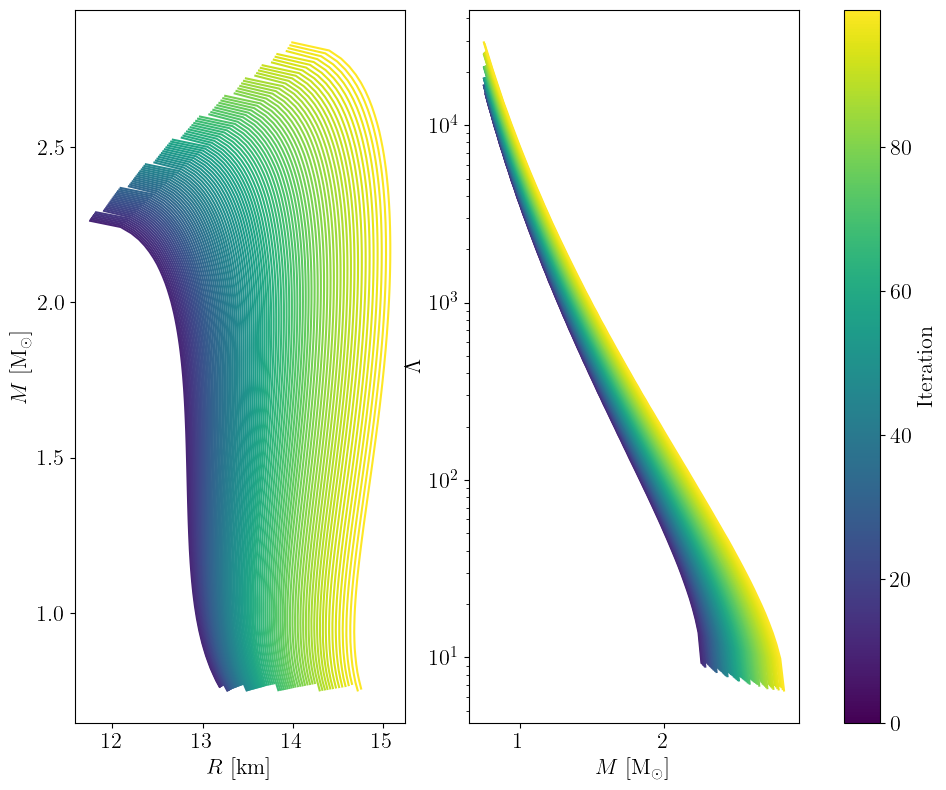

In [25]:
trajectory = run(
    score_fn_mtov,
    starting_parameters,
    fixed_params,
    sign=-1,
    nb_steps=100,
    learning_rate=1e-3,
)
plot_trajectory(trajectory, first_iteration=10)  # skip burn-in
plt.show()
plt.close()

### Towards target radius at 1.4 solar mass

Computing by gradient ascent . . .


Iteration 149: score 0.20767304643313267: 100%|██████████| 150/150 [00:34<00:00,  4.31it/s]


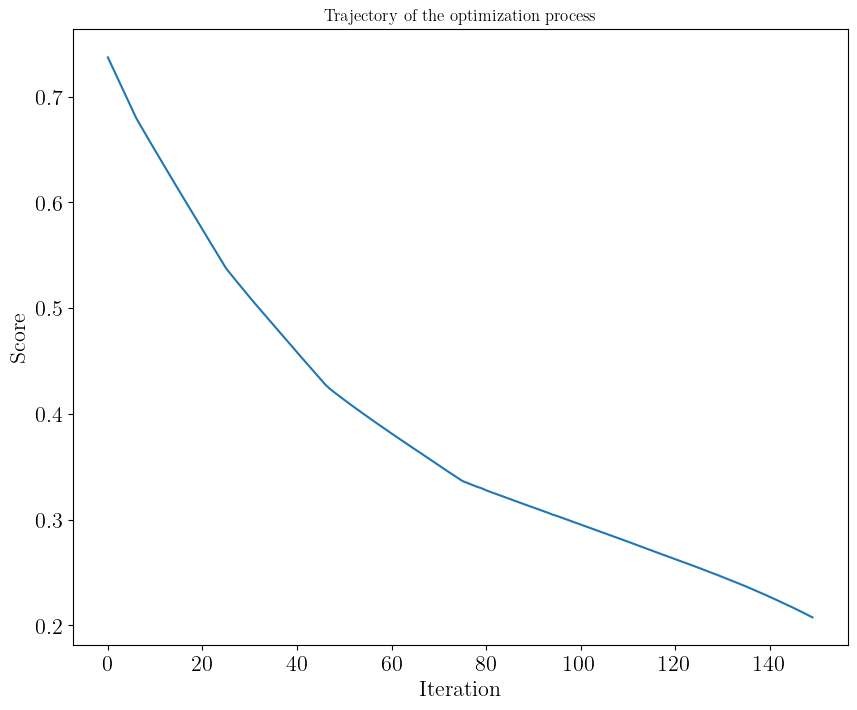

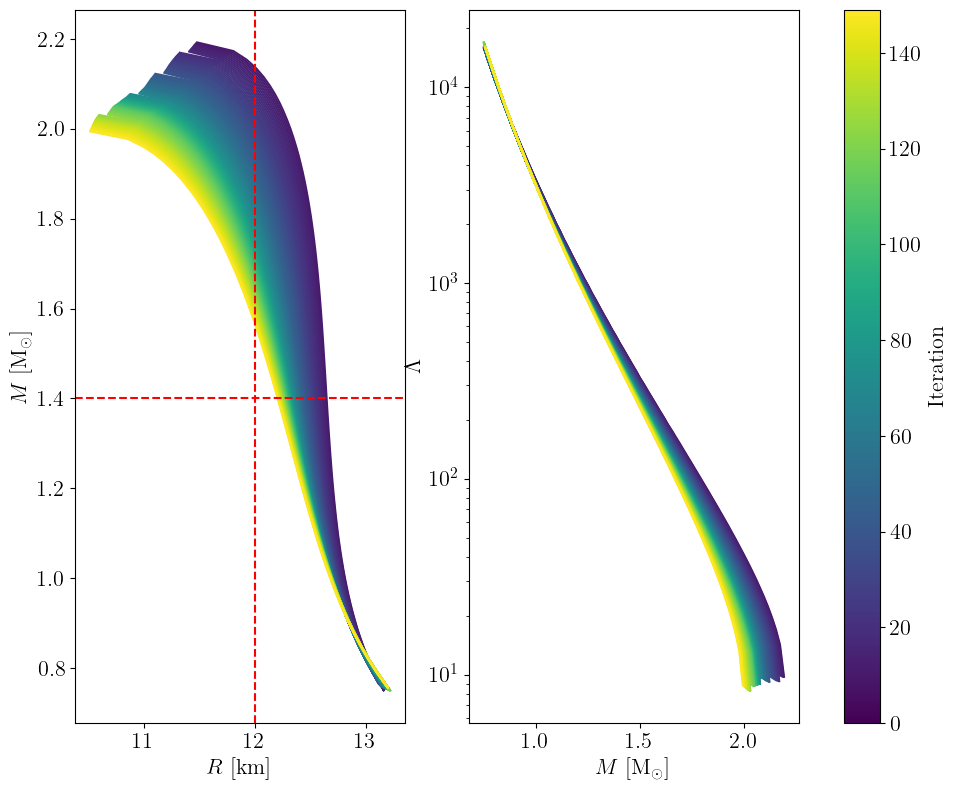

In [26]:
trajectory = run(
    score_fn_radius,
    starting_parameters,
    fixed_params,
    sign=+1,
    nb_steps=150,
    learning_rate=1e-3,
)
plot_trajectory(
    trajectory, plot_score=True, first_iteration=10
)  # plot_score: to show convergence, skip burn-in
plt.subplot(121)
plt.axhline(y=1.4, color="r", linestyle="--")
plt.axvline(x=12.0, color="r", linestyle="--")
plt.show()
plt.close()

### Parameter trajectory

For this final example, let us show the trajectory of the parameters during the optimization process to show that all of them evolve somewhat independently (although some are more correlated than others).

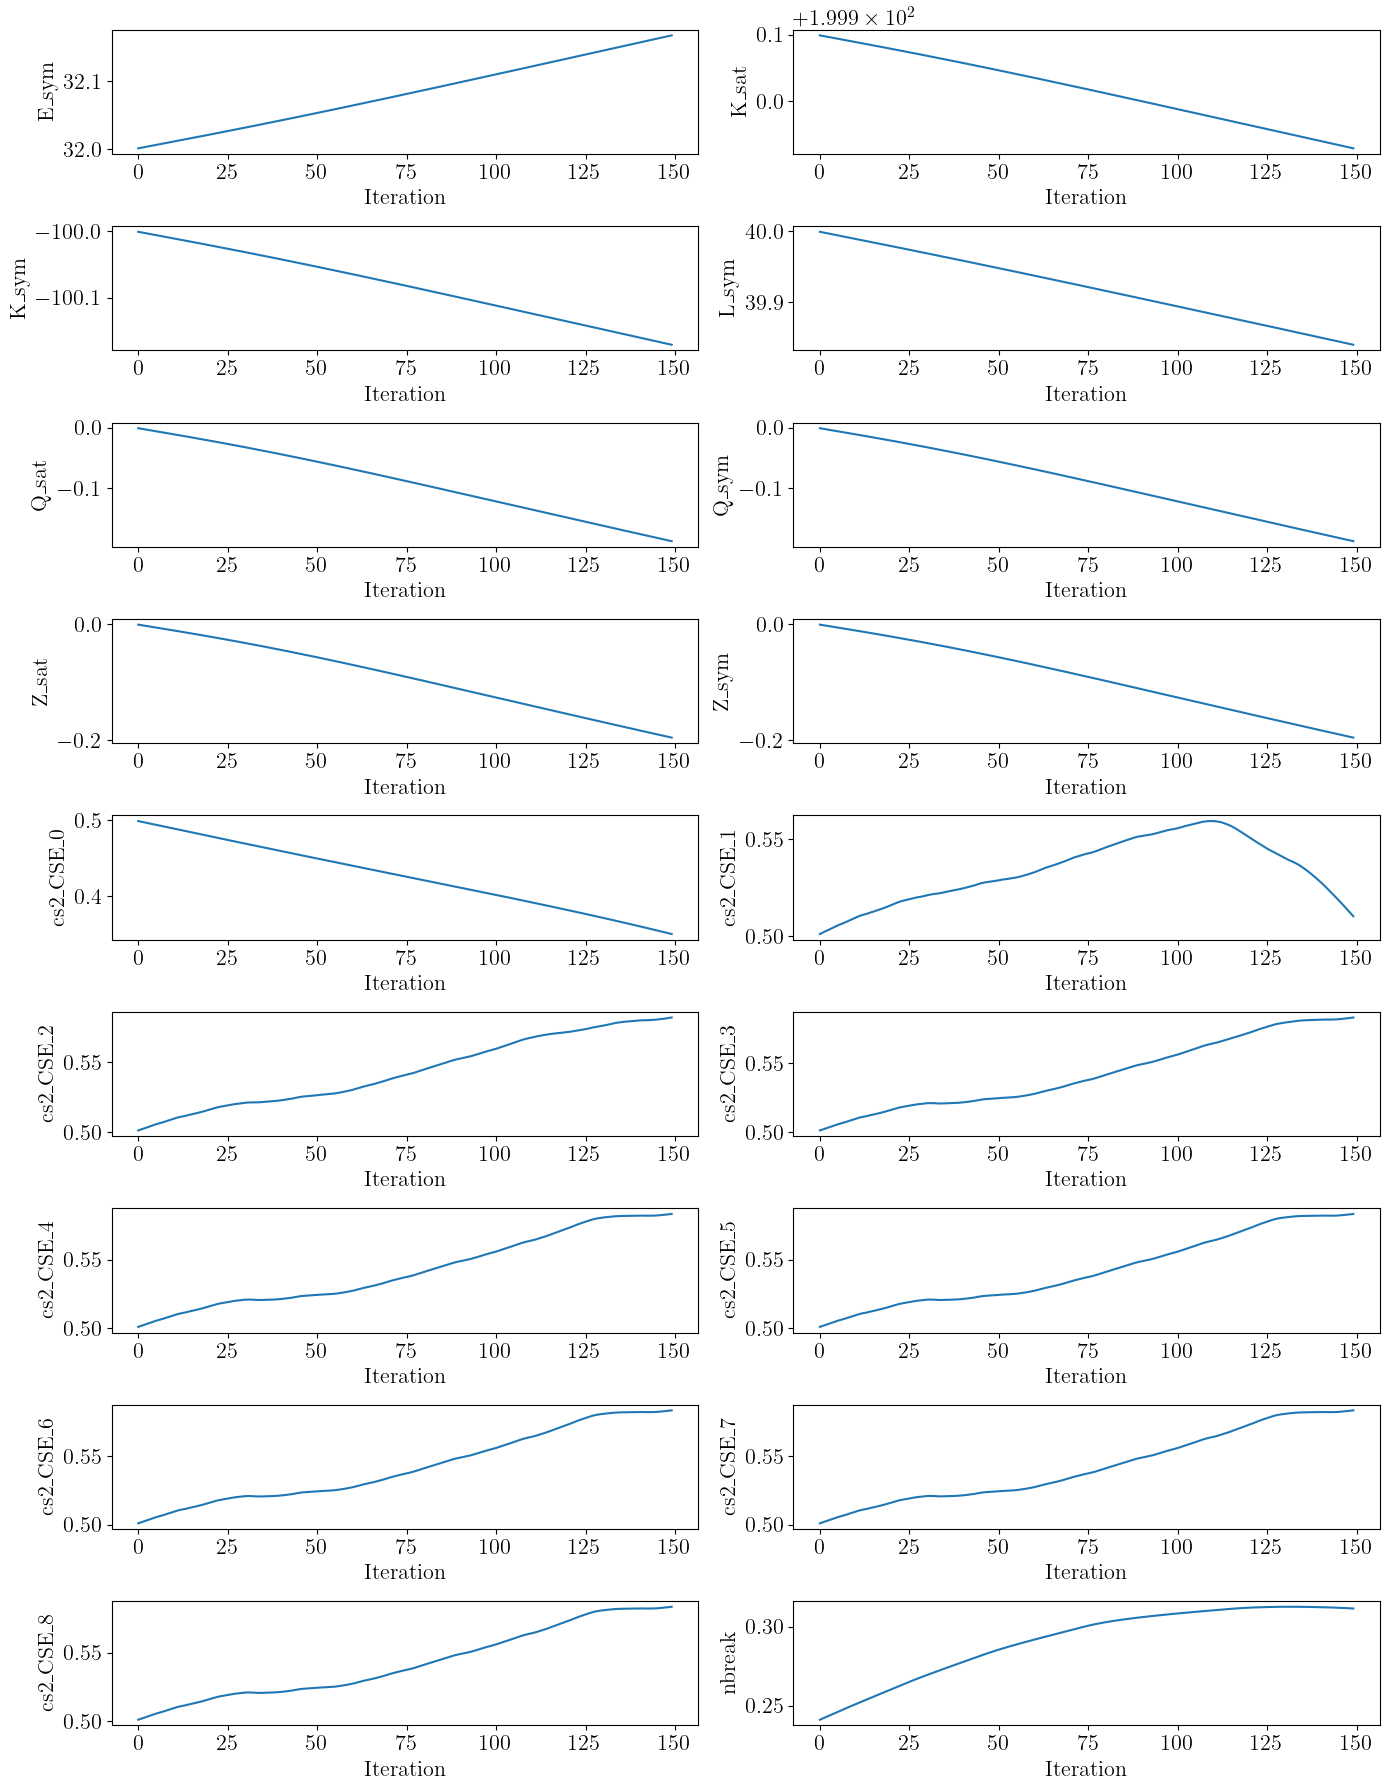

In [27]:
# Get names of parameters that are not fixed
param_names = [
    name for name in trajectory[0]["params"].keys() if name not in fixed_params.keys()
]

n_params = len(param_names)
n_rows, n_cols = (
    9,
    2,
)  # watch out: this is for the specific case of fixed parameters considered here by default!

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 18))
axes = axes.flatten()

for idx, name in enumerate(param_names):
    ax = axes[idx]
    ax.plot([trajectory[i]["params"][name] for i in trajectory.keys()])
    ax.set_xlabel("Iteration")
    ax.set_ylabel(name)

# Hide any unused subplots (if fewer than 18)
for j in range(len(param_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
plt.close()

# Closing remarks

Here, we have focused on an 18-dimensional parameter space for simplicity, but we could easily extend this to the full `jester` model defined above, which makes us require less steps for a converged run. The runtime is basically the same -- this is the power of JAX!

starting_parameters are: (27 in total)
{'K_sat': 200.0, 'Q_sat': 0.0, 'Z_sat': 0.0, 'E_sym': 32.0, 'L_sym': 40.0, 'K_sym': -100.0, 'Q_sym': 0.0, 'Z_sym': 0.0, 'nbreak': 0.24, 'cs2_CSE_0': 0.5, 'cs2_CSE_1': 0.5, 'cs2_CSE_2': 0.5, 'cs2_CSE_3': 0.5, 'cs2_CSE_4': 0.5, 'cs2_CSE_5': 0.5, 'cs2_CSE_6': 0.5, 'cs2_CSE_7': 0.5, 'cs2_CSE_8': 0.5, 'E_sat': -16.0, 'n_CSE_0_u': 0.1111111111111111, 'n_CSE_1_u': 0.2222222222222222, 'n_CSE_2_u': 0.3333333333333333, 'n_CSE_3_u': 0.4444444444444444, 'n_CSE_4_u': 0.5555555555555556, 'n_CSE_5_u': 0.6666666666666666, 'n_CSE_6_u': 0.7777777777777778, 'n_CSE_7_u': 0.8888888888888888}
Computing by gradient ascent . . .


Iteration 99: score 0.0011109136872846648: 100%|██████████| 100/100 [00:26<00:00,  3.77it/s]


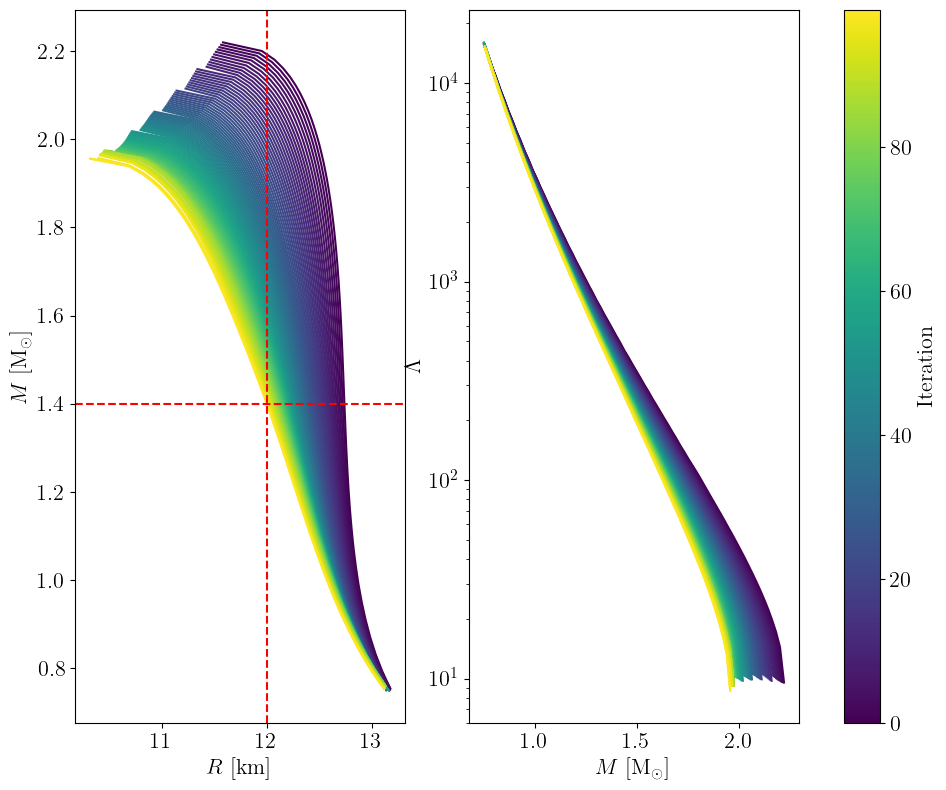

In [30]:
starting_parameters.update(fixed_params)

print(f"starting_parameters are: ({len(starting_parameters)} in total)")
print(starting_parameters)

trajectory = run(
    score_fn_radius,
    starting_parameters,
    {},
    sign=+1,
    nb_steps=100,
    learning_rate=1e-3,
)
plot_trajectory(trajectory)
plt.subplot(121)
plt.axhline(y=1.4, color="r", linestyle="--")
plt.axvline(x=12.0, color="r", linestyle="--")
plt.show()
plt.close()